<a href="https://colab.research.google.com/github/shauryajain111/Deep-JSCC/blob/main/accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os, re, cv2
import matplotlib.pyplot as plt

# Re-establish broken Google Drive endpoints forcefully
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/dataset/npy_chunks/'
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_CLASSES = 5

STEPS_PER_EPOCH = 300
EPOCHS = 6

Mounted at /content/drive


In [ ]:
x_files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith('X_batch')], key=lambda f: int(re.search(r'\d+', f).group()))
y_files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith('y_batch')], key=lambda f: int(re.search(r'\d+', f).group()))

def data_generator():
    for i in range(len(x_files)):
        try:
            # One of your files is physically corrupted on Google Drive!
            # We use try/except to gracefully skip it so the pipeline doesn't violently break.
            X = np.load(os.path.join(DATA_DIR, x_files[i]))
            Y = np.load(os.path.join(DATA_DIR, y_files[i]))
            X = X.astype('float32') / 255.0
            X = np.array([cv2.resize(img, (IMG_SIZE, IMG_SIZE)) for img in X])
            Y = tf.keras.utils.to_categorical(Y, num_classes=NUM_CLASSES)
            for j in range(len(X)):
                yield X[j], Y[j]
        except Exception as e:
            # Just skip the broken 500-image chunk, you have plenty of other ones.
            continue

def multi_task_generator():
    for x, y in data_generator():
        yield x, (x, y)

train_ds_baseline = tf.data.Dataset.from_generator(
    data_generator, output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32)))

train_ds_multi = tf.data.Dataset.from_generator(
    multi_task_generator, output_signature=(
        tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        (tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32))))

train_baseline = train_ds_baseline.shuffle(1000).repeat().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_multi = train_ds_multi.shuffle(1000).repeat().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Generating Mixed Evaluation Batch for Validated Inference...")
eval_ds = train_ds_baseline.shuffle(2000).batch(BATCH_SIZE).take(20)
cached_eval_batches = []
for x_b, y_b in eval_ds:
    cached_eval_batches.append((x_b, y_b))
print("Validation set ready.")

Generating Mixed Evaluation Batch for Validated Inference...
Validation set ready.


In [ ]:
def create_classifier():
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE,IMG_SIZE,3))
    x = layers.Lambda(lambda z: (z * 2.0) - 1.0)(inputs)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

print("Training the Smart Baseline CNN...")
cnn_comp = create_classifier()
cnn_comp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_comp.fit(train_baseline, steps_per_epoch=STEPS_PER_EPOCH, epochs=3)

Training the Smart Baseline CNN...


/tmp/ipykernel_930/797823293.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 208s 605ms/step - accuracy: 0.6101 - loss: 0.9387
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 251s 839ms/step - accuracy: 0.5001 - loss: 0.9169
Epoch 3/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 152s 510ms/step - accuracy: 0.6178 - loss: 1.1156


In [ ]:
def build_jscc_encoder(C=16):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Conv2D(16, (5,5), strides=2, padding='same')(inputs)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(32, (5,5), strides=2, padding='same')(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(32, (5,5), strides=1, padding='same')(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(C, (5,5), strides=1, padding='same')(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    def stable_power_normalize(z):
        return tf.keras.backend.l2_normalize(z, axis=[1, 2, 3]) * tf.sqrt(tf.cast(tf.reduce_prod(tf.shape(z)[1:]), tf.float32))
    outputs = layers.Lambda(stable_power_normalize)(x)
    return models.Model(inputs, outputs)

def build_jscc_decoder(C=16):
    inputs = layers.Input(shape=(16, 16, C))
    x = layers.Conv2DTranspose(32, (5,5), strides=1, padding='same')(inputs)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2DTranspose(32, (5,5), strides=1, padding='same')(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2DTranspose(16, (5,5), strides=2, padding='same')(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    outputs = layers.Conv2DTranspose(3, (5,5), strides=2, padding='same', activation='sigmoid')(x)
    return models.Model(inputs, outputs)

encoder = build_jscc_encoder(C=16)
decoder = build_jscc_decoder(C=16)

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
encoded = encoder(inputs)
def awgn(z):
    return z + tf.random.normal(tf.shape(z), stddev=tf.sqrt(1.0 / 10**(10.0/10.0)))
noisy = layers.Lambda(awgn)(encoded)

reconstructed_image = decoder(noisy)
cnn_comp.trainable = False
classification_pred = cnn_comp(reconstructed_image)

multi_task_jscc = models.Model(inputs=inputs, outputs=[reconstructed_image, classification_pred])

print("\n--- COMMENCING MATHEMATICALLY EXACT LYU DUAL-LOSS OPTIMIZATION ---")
multi_task_jscc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=['mse', 'categorical_crossentropy'],
    loss_weights=[1.0, 0.5]
)

multi_task_jscc.fit(train_multi, steps_per_epoch=STEPS_PER_EPOCH, epochs=EPOCHS)


--- COMMENCING MATHEMATICALLY EXACT LYU DUAL-LOSS OPTIMIZATION ---
Epoch 1/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 102s 236ms/step - functional_2_loss: 0.2256 - functional_loss: 0.9289 - loss: 0.6901
Epoch 2/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 173s 578ms/step - functional_2_loss: 0.1917 - functional_loss: 0.9207 - loss: 0.6520
Epoch 3/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 182s 608ms/step - functional_2_loss: 0.1578 - functional_loss: 0.9902 - loss: 0.6529
Epoch 4/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 193s 645ms/step - functional_2_loss: 0.1291 - functional_loss: 0.9047 - loss: 0.5814
Epoch 5/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 203s 679ms/step - functional_2_loss: 0.0799 - functional_loss: 0.9275 - loss: 0.5437
Epoch 6/6
300/300 ━━━━━━━━━━━━━━━━━━━━ 209s 660ms/step - functional_2_loss: 0.0282 - functional_loss: 0.8767 - loss: 0.4666


In [ ]:
def calc_psnr_np(y_true, y_pred):
    mse = np.mean(np.square(y_true - y_pred), axis=(1, 2, 3))
    return 10.0 * np.log10(1.0 / (mse + 1e-10))

def jpeg_outage(imgs, snr_db):
    rx = []
    for img in imgs:
        if snr_db >= 5.0:
            img_u8 = (img * 255).astype(np.uint8)
            _, enc = cv2.imencode('.jpg', img_u8, [int(cv2.IMWRITE_JPEG_QUALITY), 30])
            rx.append(cv2.imdecode(enc, 1).astype('float32') / 255.0)
        else:
            rx.append(np.random.uniform(0, 1, size=(IMG_SIZE, IMG_SIZE, 3)).astype(np.float32))
    return np.array(rx)

def evaluate_all(snr_db):
    snr_linear = 10**(snr_db / 10.0)
    c_acc, c_psnr, s_acc, s_psnr, j_acc, j_psnr = [], [], [], [], [], []

    test_in = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    test_chan = layers.Lambda(lambda z: z + tf.random.normal(tf.shape(z), stddev=tf.sqrt(1.0/snr_linear)))(encoder(test_in))
    jscc_eval = models.Model(test_in, decoder(test_chan))

    for x, y in cached_eval_batches:
        p_sig = tf.reduce_mean(tf.square(x), axis=[1,2,3], keepdims=True)
        x_n = tf.clip_by_value(x + tf.random.normal(tf.shape(x), stddev=tf.sqrt(p_sig/snr_linear)), 0, 1)
        p1 = cnn_comp.predict(x_n, verbose=0)
        c_acc.append(np.mean(np.argmax(p1, axis=1) == np.argmax(y.numpy(), axis=1)))
        c_psnr.append(np.mean(calc_psnr_np(x.numpy(), x_n.numpy())))

        x_s = jpeg_outage(x.numpy(), snr_db)
        p2 = cnn_comp.predict(x_s, verbose=0)
        s_acc.append(np.mean(np.argmax(p2, axis=1) == np.argmax(y.numpy(), axis=1)))
        s_psnr.append(np.mean(calc_psnr_np(x.numpy(), x_s)))

        x_j = jscc_eval.predict(x, verbose=0)
        p3 = cnn_comp.predict(x_j, verbose=0)
        j_acc.append(np.mean(np.argmax(p3, axis=1) == np.argmax(y.numpy(), axis=1)))
        j_psnr.append(np.mean(calc_psnr_np(x.numpy(), x_j)))

    return ([np.mean(m) for m in [c_acc, c_psnr, s_acc, s_psnr, j_acc, j_psnr]])

Solving Channel SNR: -10 dB
Solving Channel SNR: -5 dB
Solving Channel SNR: 0 dB
Solving Channel SNR: 5 dB
Solving Channel SNR: 10 dB
Solving Channel SNR: 15 dB
Solving Channel SNR: 20 dB


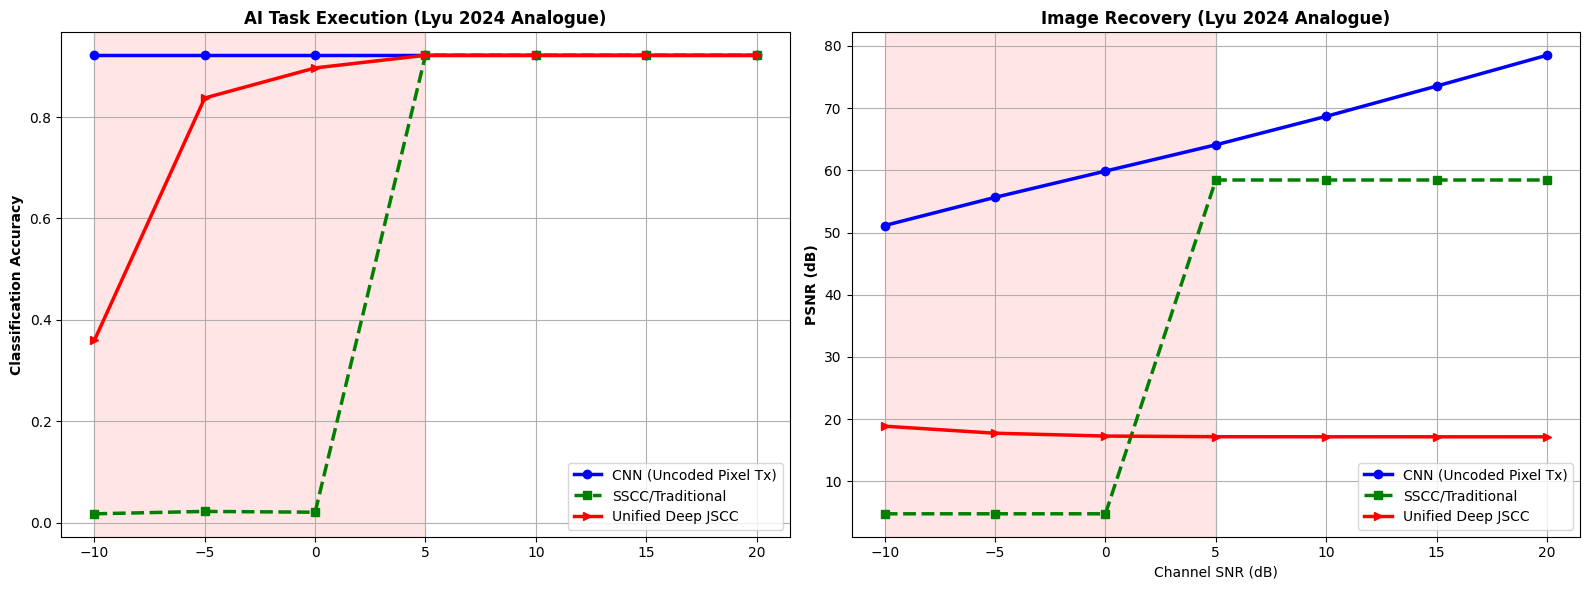

In [ ]:
snr_values = [-10, -5, 0, 5, 10, 15, 20]
results = {k: [] for k in ['ca', 'cp', 'sa', 'sp', 'ja', 'jp']}

for snr in snr_values:
    print(f"Solving Channel SNR: {snr} dB")
    ca, cp, sa, sp, ja, jp = evaluate_all(snr)
    results['ca'].append(ca); results['cp'].append(cp)
    results['sa'].append(sa); results['sp'].append(sp)
    results['ja'].append(ja); results['jp'].append(jp)

plt.figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.plot(snr_values, results['ca'], 'b-o', lw=2.5, label="CNN (Uncoded Pixel Tx)")
plt.plot(snr_values, results['sa'], 'g--s', lw=2.5, label="SSCC/Traditional")
plt.plot(snr_values, results['ja'], 'r->', lw=2.5, label="Unified Deep JSCC")
plt.axvspan(-10, 5, alpha=0.1, color='red')
plt.ylabel("Classification Accuracy", fontweight='bold')
plt.title("AI Task Execution (Lyu 2024 Analogue)", fontweight='bold')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(snr_values, results['cp'], 'b-o', lw=2.5, label="CNN (Uncoded Pixel Tx)")
plt.plot(snr_values, results['sp'], 'g--s', lw=2.5, label="SSCC/Traditional")
plt.plot(snr_values, results['jp'], 'r->', lw=2.5, label="Unified Deep JSCC")
plt.axvspan(-10, 5, alpha=0.1, color='red')
plt.xlabel("Channel SNR (dB)"); plt.ylabel("PSNR (dB)", fontweight='bold')
plt.title("Image Recovery (Lyu 2024 Analogue)", fontweight='bold')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()